<a href="https://colab.research.google.com/github/slittle95/spanish-prepositions/blob/main/create_dissimilarity_matrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
#after deleting unused prepositions by hand
m = pd.read_csv("countMatrix.txt", sep='\t', index_col=0)[:]
m = m.drop(columns=['del','a']) #'del' is on purpose for deleting, 'a' just covers too many definitions to not complicate things
m = m.transpose()
display(m.head())

,AD,AT,CA,COA,COM,COMP,CO,DE,DI,IS,...,PU,RE,RS,RT,SO,SP,SS,ST,TD,TO
bajo,0,0,2,0,0,0,0,0,0,0,...,0,0,3,0,0,0,0,0,0,0
con,0,0,0,16,9,0,31,0,0,0,...,0,0,0,0,0,0,0,0,0,0
de,9,2,5,0,0,15,8,1,0,2,...,3,1,21,14,29,189,2,2,0,40
desde,0,0,0,0,0,0,0,0,0,0,...,0,0,0,4,6,0,0,0,0,0
durante,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,3,0,0


In [ ]:
# Sanity check:
# Get column names
column_names = m.columns.tolist()
print("Column Names:")
print(column_names)
# Get row names (index)
row_names = m.index.tolist()
print("\nRow Names (Index):")
print(row_names)

Column Names:
['AD', 'AT', 'CA', 'COA', 'COM', 'COMP', 'CO', 'DE', 'DI', 'IS', 'IT', 'IN', 'ME', 'MO', 'MOM', 'PE', 'POS', 'PU', 'RE', 'RS', 'RT', 'SO', 'SP', 'SS', 'ST', 'TD', 'TO']


In [ ]:
row_names_per_column = []

for col in m.columns:
    # Get row names where the value in the current column is greater than 0
    relevant_row_names = m[m[col] > 0].index.tolist()
    # Convert the list of row names to a set and append to the result list
    # Every semantic function gets a set of prepositions
    row_names_per_column.append(set(relevant_row_names))

length = len(row_names_per_column)
for i in range(length):
  print(i, column_names[i], row_names_per_column[i],'\n')

0 AD {'de', 'sin'} 

1 AT {'de', 'por'} 

2 CA {'de', 'por', 'bajo'} 

3 COA {'con'} 

4 COM {'con'} 

5 COMP {'de', 'en'} 

6 CO {'de', 'con'} 

7 DE {'para', 'de', 'hasta', 'en'} 

8 DI {'por'} 

9 IS {'durante', 'de', 'en', 'por'} 

10 IT {'durante', 'por', 'sobre', 'de', 'en'} 

11 IN {'de', 'por'} 

12 ME {'con', 'por'} 

13 MO {'de', 'en', 'por'} 

14 MOM {'de', 'en'} 

15 PE {'para', 'de'} 

16 POS {'de', 'con'} 

17 PU {'para', 'de', 'por'} 

18 RE {'para', 'de', 'en', 'por'} 

19 RS {'bajo', 'sobre', 'de', 'en', 'entre'} 

20 RT {'desde', 'de', 'hasta', 'en', 'entre'} 

21 SO {'desde', 'de', 'por'} 

22 SP {'de', 'en', 'por'} 

23 SS {'para', 'de', 'en'} 

24 ST {'durante', 'de', 'en'} 

25 TD {'para', 'en'} 

26 TO {'sobre', 'de', 'en', 'por'} 



In [ ]:
def whats_the_difference(column1, column2):
  i = row_names_per_column[column1].difference(row_names_per_column[column2])
  #the literal set definition of difference--what prepositions make these two functions different?
  return len(i)

In [ ]:
# Recreate original matrix as a difference matrix where every semantic function is
# compared to every other semantic function via how many prepositions one has that
# the other does not
outer_list = []
print(column_names)
for i in range(len(column_names)):
  inner_list = []
  print(column_names[i])
  for j in range(len(column_names)):
    a = whats_the_difference(i, j)
    inner_list.append(a)
  outer_list.append(inner_list)
  print(inner_list)

['AD', 'AT', 'CA', 'COA', 'COM', 'COMP', 'CO', 'DE', 'DI', 'IS', 'IT', 'IN', 'ME', 'MO', 'MOM', 'PE', 'POS', 'PU', 'RE', 'RS', 'RT', 'SO', 'SP', 'SS', 'ST', 'TD', 'TO']
AD
[0, 1, 1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1]
AT
[1, 0, 0, 2, 2, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 2, 0]
CA
[2, 1, 0, 3, 3, 2, 2, 2, 2, 1, 1, 1, 2, 1, 2, 2, 2, 1, 1, 1, 2, 1, 1, 2, 2, 3, 1]
COA
[1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
COM
[1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
COMP
[1, 1, 1, 2, 2, 0, 1, 0, 2, 0, 0, 1, 2, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0]
CO
[1, 1, 1, 1, 1, 1, 0, 1, 2, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1]
DE
[3, 3, 3, 4, 4, 2, 3, 0, 4, 2, 2, 3, 4, 2, 2, 2, 3, 2, 1, 2, 1, 3, 2, 1, 2, 2, 2]
DI
[1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0]
IS
[3, 2, 2, 4, 4, 2, 3, 2, 3, 0, 0, 2, 3, 1, 2, 3, 3, 2, 1, 2

In [ ]:
import csv
with open('integer_dissimilarity.csv', 'w', newline='') as csvfile:
    csvwriter = csv.writer(csvfile)
    for i in range(len(column_names)):
      inner_list = []
      for j in range(len(column_names)):
        a = whats_the_difference(i, j)
        inner_list.append(a)
      csvwriter.writerow(inner_list)

In [ ]:
# Install matplotlib-venn for Venn diagram visualization
%pip install matplotlib-venn

In [ ]:
col_names_per_row = []

for row in m.index:
    # Get column names where the value in the current row is greater than 0
    relevant_column_names = m.loc[row, m.loc[row] > 0].index
    col_names_per_row.append(set(relevant_column_names))

length = len(col_names_per_row)
for i in range(length):
  print(i, row_names[i], col_names_per_row[i],'\n')


0 bajo {'RS', 'CA'} 

1 con {'CO', 'COA', 'COM', 'POS', 'ME'} 

2 de {'CA', 'IS', 'AD', 'RS', 'CO', 'SS', 'AT', 'COMP', 'PE', 'PU', 'MO', 'RE', 'IN', 'RT', 'SO', 'ST', 'TO', 'DE', 'MOM', 'IT', 'SP', 'POS'} 

3 desde {'SO', 'RT'} 

4 durante {'IT', 'IS', 'ST'} 

5 en {'ST', 'IS', 'DE', 'RS', 'SS', 'MO', 'RE', 'MOM', 'TD', 'RT', 'IT', 'SP', 'COMP', 'TO'} 

6 entre {'RS', 'RT'} 

7 hasta {'RT', 'DE'} 

8 por {'CA', 'IS', 'PU', 'MO', 'AT', 'RE', 'IN', 'SP', 'IT', 'DI', 'SO', 'ME', 'TO'} 

9 para {'PE', 'DE', 'PU', 'SS', 'RE', 'TD'} 

10 sin {'AD'} 

11 sobre {'IT', 'RS', 'TO'} 



In [ ]:
from matplotlib_venn import venn2, venn3
import matplotlib.pyplot as plt



3-Set Venn Diagram for con ({'CO', 'COA', 'COM', 'POS', 'ME'}), de ({'CA', 'IS', 'AD', 'RS', 'CO', 'SS', 'AT', 'COMP', 'PE', 'PU', 'MO', 'RE', 'IN', 'RT', 'SO', 'ST', 'TO', 'DE', 'MOM', 'IT', 'SP', 'POS'}), and durante ({'IT', 'IS', 'ST'})
Only in con: {'COM', 'COA', 'ME'}
Only in de: {'CA', 'PE', 'AD', 'RS', 'PU', 'MO', 'RE', 'IN', 'RT', 'SO', 'TO', 'DE', 'SS', 'AT', 'MOM', 'SP', 'COMP'}
Only in durante: set()
In con and de only: {'CO', 'POS'}
In con and durante only: set()
In de and durante only: {'IT', 'IS', 'ST'}
In all three: set()


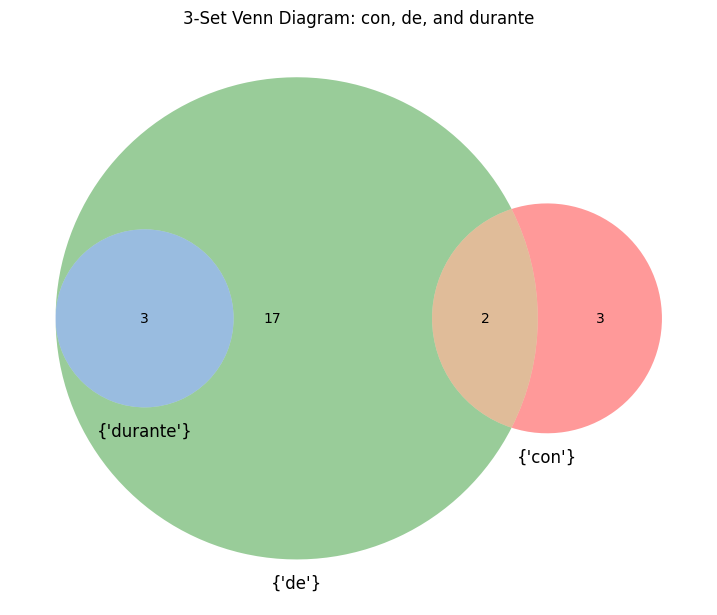

In [ ]:
set_A = col_names_per_row[1] # {'CA', 'RS'}
set_B = col_names_per_row[2] # {'CO', 'COM', 'POS', 'RS', 'COA', 'ME'}
set_C = col_names_per_row[4] # {'CO', 'COM', 'POS', 'RS', 'COA', 'ME'}

print(f"\n3-Set Venn Diagram for {row_names[1]} ({set_A}), {row_names[2]} ({set_B}), and {row_names[4]} ({set_C})")
print(f"Only in {row_names[1]}: {set_A - set_B - set_C}")
print(f"Only in {row_names[2]}: {set_B - set_A - set_C}")
print(f"Only in {row_names[4]}: {set_C - set_A - set_B}")
print(f"In {row_names[1]} and {row_names[2]} only: {(set_A & set_B) - set_C}")
print(f"In {row_names[1]} and {row_names[4]} only: {(set_A & set_C) - set_B}")
print(f"In {row_names[2]} and {row_names[4]} only: {(set_B & set_C) - set_A}")
print(f"In all three: {set_A & set_B & set_C}")

plt.figure(figsize=(9, 9))
venn3([set_A, set_B, set_C], ({row_names[1]}, {row_names[2]}, {row_names[4]}))
plt.title(f"3-Set Venn Diagram: {row_names[1]}, {row_names[2]}, and {row_names[4]}")
plt.show()


3-Set Venn Diagram for hasta ({'RT', 'DE'}), de ({'CA', 'IS', 'AD', 'RS', 'CO', 'SS', 'AT', 'COMP', 'PE', 'PU', 'MO', 'RE', 'IN', 'RT', 'SO', 'ST', 'TO', 'DE', 'MOM', 'IT', 'SP', 'POS'}), and durante ({'IT', 'IS', 'ST'})
Only in hasta: set()
Only in de: {'CA', 'PE', 'AD', 'RS', 'PU', 'CO', 'MO', 'RE', 'IN', 'SO', 'TO', 'SS', 'AT', 'MOM', 'SP', 'POS', 'COMP'}
Only in durante: set()
In hasta and de only: {'RT', 'DE'}
In hasta and durante only: set()
In de and durante only: {'IT', 'IS', 'ST'}
In all three: set()


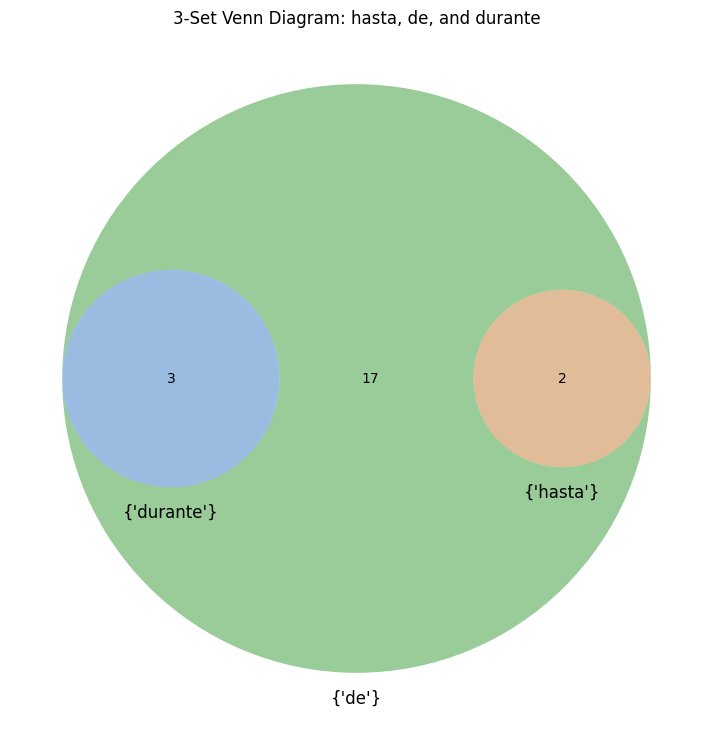

In [ ]:
# Select the first three non-empty sets from col_names_per_row
set_A = col_names_per_row[7] # {'RE', 'SP', 'SS', 'TD', 'IT', 'MO', 'TO', 'IS', 'ST', 'ID', 'DE'}
set_B = col_names_per_row[2] # {'CO', 'COM', 'POS', 'RS', 'COA', 'ME'}
set_C = col_names_per_row[4] # {'RT', 'PU', 'CO', 'RE', 'POS', 'SP', 'PE', 'AT', 'SS', 'RS', 'MO', 'CA', 'SO', 'TO', 'ID'}

print(f"\n3-Set Venn Diagram for {row_names[7]} ({set_A}), {row_names[2]} ({set_B}), and {row_names[4]} ({set_C})")
print(f"Only in {row_names[7]}: {set_A - set_B - set_C}")
print(f"Only in {row_names[2]}: {set_B - set_A - set_C}")
print(f"Only in {row_names[4]}: {set_C - set_A - set_B}")
print(f"In {row_names[7]} and {row_names[2]} only: {(set_A & set_B) - set_C}")
print(f"In {row_names[7]} and {row_names[4]} only: {(set_A & set_C) - set_B}")
print(f"In {row_names[2]} and {row_names[4]} only: {(set_B & set_C) - set_A}")
print(f"In all three: {set_A & set_B & set_C}")

plt.figure(figsize=(9, 9))
venn3([set_A, set_B, set_C], ({row_names[7]}, {row_names[2]}, {row_names[4]}))
plt.title(f"3-Set Venn Diagram: {row_names[7]}, {row_names[2]}, and {row_names[4]}")
plt.show()


3-Set Venn Diagram for con ({'CO', 'COA', 'COM', 'POS', 'ME'}), de ({'CA', 'IS', 'AD', 'RS', 'CO', 'SS', 'AT', 'COMP', 'PE', 'PU', 'MO', 'RE', 'IN', 'RT', 'SO', 'ST', 'TO', 'DE', 'MOM', 'IT', 'SP', 'POS'}), and durante ({'RT', 'DE'})
Only in con: {'COM', 'COA', 'ME'}
Only in de: {'CA', 'PE', 'IS', 'AD', 'RS', 'PU', 'MO', 'RE', 'IN', 'SO', 'ST', 'TO', 'SS', 'AT', 'MOM', 'IT', 'SP', 'COMP'}
Only in hasta: set()
In con and de only: {'CO', 'POS'}
In con and hasta only: set()
In de and hasta only: {'RT', 'DE'}
In all three: set()


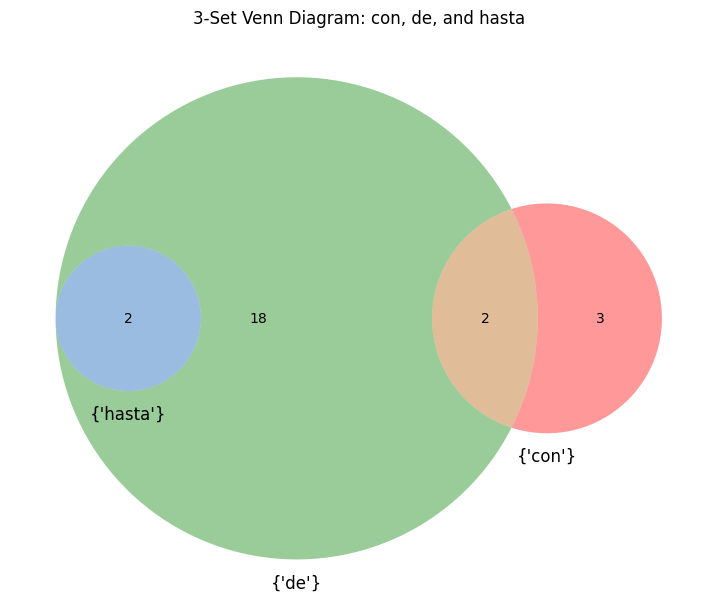

In [ ]:
# Select the first three non-empty sets from col_names_per_row
set_A = col_names_per_row[1] # {'CA', 'RS'}
set_B = col_names_per_row[2] # {'CO', 'COM', 'POS', 'RS', 'COA', 'ME'}
set_C = col_names_per_row[7] # {'RE', 'SP', 'SS', 'TD', 'IT', 'MO', 'TO', 'IS', 'ST', 'ID', 'DE'}

print(f"\n3-Set Venn Diagram for {row_names[1]} ({set_A}), {row_names[2]} ({set_B}), and {row_names[4]} ({set_C})")
print(f"Only in {row_names[1]}: {set_A - set_B - set_C}")
print(f"Only in {row_names[2]}: {set_B - set_A - set_C}")
print(f"Only in {row_names[7]}: {set_C - set_A - set_B}")
print(f"In {row_names[1]} and {row_names[2]} only: {(set_A & set_B) - set_C}")
print(f"In {row_names[1]} and {row_names[7]} only: {(set_A & set_C) - set_B}")
print(f"In {row_names[2]} and {row_names[7]} only: {(set_B & set_C) - set_A}")
print(f"In all three: {set_A & set_B & set_C}")

plt.figure(figsize=(9, 9))
venn3([set_A, set_B, set_C], ({row_names[1]}, {row_names[2]}, {row_names[7]}))
plt.title(f"3-Set Venn Diagram: {row_names[1]}, {row_names[2]}, and {row_names[7]}")
plt.show()

1 bajo {'CA', 'RS'}  
2 con {'CO', 'COM', 'POS', 'RS', 'COA', 'ME'}  
4 de {'RT', 'PU', 'CO', 'RE', 'POS', 'SP', 'PE', 'AT', 'SS', 'RS', 'MO', 'CA', 'SO', 'TO', 'ID'}  
7 en {'RE', 'SP', 'SS', 'TD', 'IT', 'MO', 'TO', 'IS', 'ST', 'ID', 'DE'}    
10 {'IS', 'IT'}  
11 por {'PU', 'RE', 'DI', 'AT', 'IT', 'MO', 'CA', 'SO', 'TO', 'IN', 'IS', 'ST', 'ID'}  
12 para {'PU', 'RE', 'PE', 'TD', 'DE'}  
15 sobre {'RT', 'RS', 'IT', 'TO'}
